In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data1 = pd.read_csv("data_0.csv")
data2 = pd.read_csv("data_0.5.csv")
data3 = pd.read_csv("data_1.csv")
data4 = pd.read_csv("data_1.5.csv")
data5 = pd.read_csv("data_2.csv")
data6 = pd.read_csv("data_2.5.csv")
data7 = pd.read_csv("data_3.csv")
data8 = pd.read_csv("data_3.5.csv")
data9 = pd.read_csv("data_4.csv")
data10 = pd.read_csv("data_4.5.csv")
data11 = pd.read_csv("data_5.csv")

# Every variable is redshifted 500'000'000 years per .5. ...
# ...EXE: data1 = local, data2 = 500'000'000 data3 = 1'000'000'000, etc.

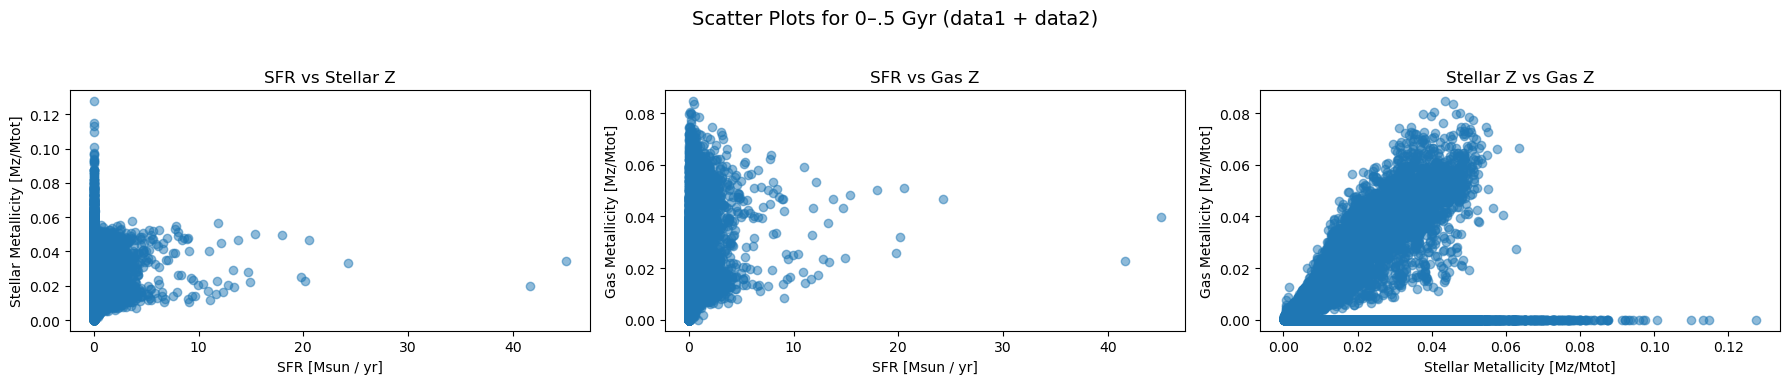

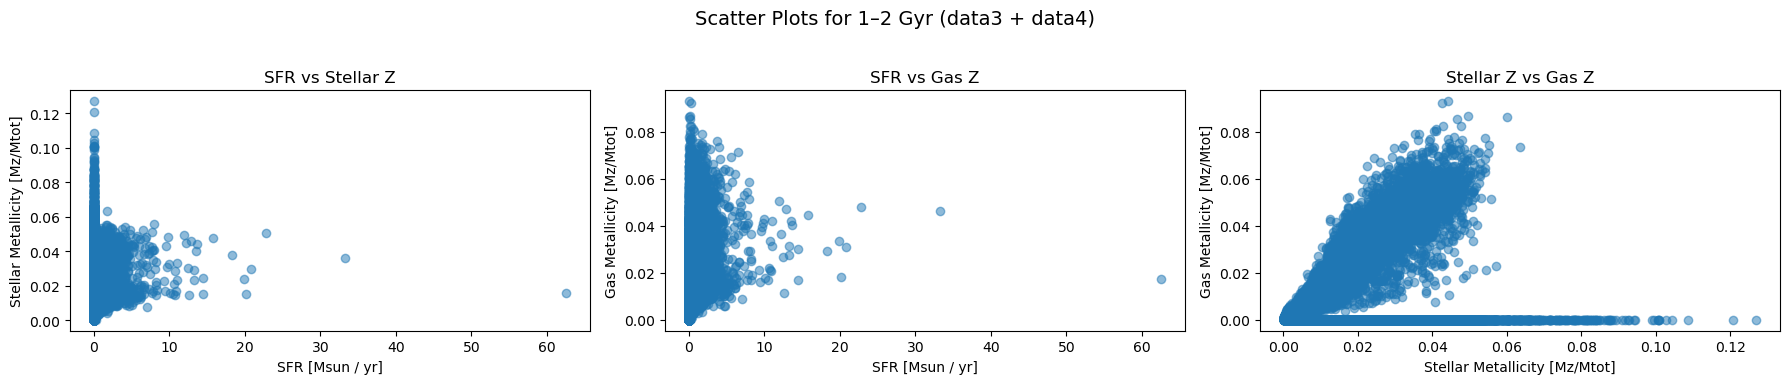


KeyboardInterrupt



In [2]:
groups = [
    [data1, data2],  # local–.5 Gyr
    [data3, data4],  # 1–2 Gyr
    [data5, data6],  # 2–3 Gyr
    [data7, data8],  # 3–4 Gyr
    [data9, data10], # 4–5 Gyr
    [data11]         # 5+ Gyr
]
# Group labels for plot titles
group_labels = [
    "0–.5 Gyr (data1 + data2)",
    "1–2 Gyr (data3 + data4)",
    "2–3 Gyr (data5 + data6)",
    "3–4 Gyr (data7 + data8)",
    "4–5 Gyr (data9 + data10)",
    "5–6 Gyr (data11)"
]

# Plot each group's scatter plots
for i, group in enumerate(groups):
    combined = pd.concat(group)

    fig, axs = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"Scatter Plots for {group_labels[i]}", fontsize=14)

    # SFR vs Stellar Metallicity
    axs[0].scatter(combined["SFR [Msun / yr]"], combined["Stellar Metallicity [Mz/Mtot]"], alpha=0.5)
    axs[0].set_xlabel("SFR [Msun / yr]")
    axs[0].set_ylabel("Stellar Metallicity [Mz/Mtot]")
    axs[0].set_title("SFR vs Stellar Z")

    # SFR vs Gas Metallicity
    axs[1].scatter(combined["SFR [Msun / yr]"], combined["Gas Metallicity [Mz/Mtot]"], alpha=0.5)
    axs[1].set_xlabel("SFR [Msun / yr]")
    axs[1].set_ylabel("Gas Metallicity [Mz/Mtot]")
    axs[1].set_title("SFR vs Gas Z")

    # Stellar Z vs Gas Z
    axs[2].scatter(combined["Stellar Metallicity [Mz/Mtot]"], combined["Gas Metallicity [Mz/Mtot]"], alpha=0.5)
    axs[2].set_xlabel("Stellar Metallicity [Mz/Mtot]")
    axs[2].set_ylabel("Gas Metallicity [Mz/Mtot]")
    axs[2].set_title("Stellar Z vs Gas Z")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
# Initialize lists to store averaged data
time_labels = []
avg_sfr = []
std_sfr = []
avg_stellarZ = []
std_stellarZ = []
avg_gasZ = []
std_gasZ = []

# Loop through each group, average and compute std
for i, group in enumerate(groups):
    # Concatenate group into one DataFrame
    combined = pd.concat(group)
    
    # Compute means and stds
    sfr_mean = combined["SFR [Msun / yr]"].mean()
    sfr_std = combined["SFR [Msun / yr]"].std()
    stellarZ_mean = combined["Stellar Metallicity [Mz/Mtot]"].mean()
    stellarZ_std = combined["Stellar Metallicity [Mz/Mtot]"].std()
    gasZ_mean = combined["Gas Metallicity [Mz/Mtot]"].mean()
    gasZ_std = combined["Gas Metallicity [Mz/Mtot]"].std()
    
    # Store results
    time_labels.append(i)  # Can be changed to actual Gyr if needed
    avg_sfr.append(sfr_mean)
    std_sfr.append(sfr_std)
    avg_stellarZ.append(stellarZ_mean)
    std_stellarZ.append(stellarZ_std)
    avg_gasZ.append(gasZ_mean)
    std_gasZ.append(gasZ_std)

# Convert time labels to Gyr
time_labels = [0.5 + i for i in time_labels]  # Midpoint of each bin in Gyr

# Plotting
plt.figure(figsize=(12, 6))

# Star Formation Rate
plt.errorbar(time_labels, avg_sfr, yerr=std_sfr, label="SFR", fmt='-o')
# Stellar Metallicity
plt.errorbar(time_labels, avg_stellarZ, yerr=std_stellarZ, label="Stellar Metallicity", fmt='-o')
# Gas Metallicity
plt.errorbar(time_labels, avg_gasZ, yerr=std_gasZ, label="Gas Metallicity", fmt='-o')

plt.xlabel("Time (Gyr)")
plt.ylabel("Value")
plt.title("Average Quantities Over Cosmic Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
print("Stellar Z Means:", avg_stellarZ)
print("Stellar Z Stddevs:", std_stellarZ)

In [ ]:
groups = [
    [data1, data2],   # 0–0.5 Gyr
    [data3, data4],   # 0.5–1.5 Gyr
    [data5, data6],   # 1.5–2.5 Gyr
    [data7, data8],   # 2.5–3.5 Gyr
    [data9, data10],  # 3.5–4.5 Gyr
    [data11]          # 4.5–5.5 Gyr
]

# Time bin midpoints (Gyr)
time_labels = [0.25, 1.0, 2.0, 3.0, 4.0, 5.0]

# === Storage for medians and IQRs ===
median_sfr, iqr_sfr = [], []
median_stellarZ, iqr_stellarZ = [], []
median_gasZ, iqr_gasZ = [], []

# === Process each time group ===
for group in groups:
    combined = pd.concat(group).dropna()

    # SFR
    sfr_median = combined["SFR [Msun / yr]"].median()
    sfr_iqr = combined["SFR [Msun / yr]"].quantile(0.75) - combined["SFR [Msun / yr]"].quantile(0.25)

    # Stellar Z
    stellarZ_median = combined["Stellar Metallicity [Mz/Mtot]"].median()
    stellarZ_iqr = combined["Stellar Metallicity [Mz/Mtot]"].quantile(0.75) - combined["Stellar Metallicity [Mz/Mtot]"].quantile(0.25)

    # Gas Z
    gasZ_median = combined["Gas Metallicity [Mz/Mtot]"].median()
    gasZ_iqr = combined["Gas Metallicity [Mz/Mtot]"].quantile(0.75) - combined["Gas Metallicity [Mz/Mtot]"].quantile(0.25)

    # Store values
    median_sfr.append(sfr_median)
    iqr_sfr.append(sfr_iqr)
    median_stellarZ.append(stellarZ_median)
    iqr_stellarZ.append(stellarZ_iqr)
    median_gasZ.append(gasZ_median)
    iqr_gasZ.append(gasZ_iqr)

# === Dual Y-Axis Plot: Median Trends Over Time ===
fig, ax1 = plt.subplots(figsize=(10, 6))

# Left y-axis: SFR
ax1.errorbar(time_labels, median_sfr, yerr=iqr_sfr, fmt='-o', color='tab:blue', label="SFR")
ax1.set_xlabel("Time (Gyr)")
ax1.set_ylabel("SFR [Msun / yr]", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Right y-axis: Metallicity
ax2 = ax1.twinx()
ax2.errorbar(time_labels, median_stellarZ, yerr=iqr_stellarZ, fmt='-o', color='tab:orange', label="Stellar Metallicity")
ax2.errorbar(time_labels, median_gasZ, yerr=iqr_gasZ, fmt='-o', color='tab:green', label="Gas Metallicity")
ax2.set_ylabel("Metallicity [Mz/Mtot]", color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.title("Median SFR and Metallicity Over Time with IQR")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Grouped Scatter Plots ===
group_labels = [
    "0–0.5 Gyr (local to 0.5 Gya)",
    "1-1.5 Gyr",
    "2-2.5 Gyr",
    "3-3.5 Gyr",
    "4-4.5 Gyr",
    "5 Gyr"
]

for i, group in enumerate(groups):
    combined = pd.concat(group).dropna()

    fig, axs = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"Scatter Plots for {group_labels[i]}", fontsize=14)

    axs[0].scatter(combined["SFR [Msun / yr]"], combined["Stellar Metallicity [Mz/Mtot]"], alpha=0.5)
    axs[0].set_xlabel("SFR [Msun / yr]")
    axs[0].set_ylabel("Stellar Metallicity [Mz/Mtot]")
    axs[0].set_title("SFR vs Stellar Z")

    axs[1].scatter(combined["SFR [Msun / yr]"], combined["Gas Metallicity [Mz/Mtot]"], alpha=0.5)
    axs[1].set_xlabel("SFR [Msun / yr]")
    axs[1].set_ylabel("Gas Metallicity [Mz/Mtot]")
    axs[1].set_title("SFR vs Gas Z")

    axs[2].scatter(combined["Stellar Metallicity [Mz/Mtot]"], combined["Gas Metallicity [Mz/Mtot]"], alpha=0.5)
    axs[2].set_xlabel("Stellar Metallicity [Mz/Mtot]")
    axs[2].set_ylabel("Gas Metallicity [Mz/Mtot]")
    axs[2].set_title("Stellar Z vs Gas Z")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [ ]:
from scipy.stats import linregress
groups = [
    [data1, data2],   # 0–0.5 Gyr
    [data3, data4],   # 1–1.5 Gyr
    [data5, data6],   # 2–2.5 Gyr
    [data7, data8],   # 3–3.5 Gyr
    [data9, data10],  # 4–4.5 Gyr
    [data11]          # 5 Gyr
]

group_labels = [
    "0–0.5 Gyr (local to 0.5 Gya)",
    "1–1.5 Gyr",
    "2–2.5 Gyr",
    "3–3.5 Gyr",
    "4–4.5 Gyr",
    "5 Gyr"
]

# Midpoints for the summary trend plot (Gyr)
time_labels = [0.25, 1.25, 2.25, 3.25, 4.25, 5.0]

# === Storage for medians and IQRs ===
median_sfr, iqr_sfr = [], []
median_stellarZ, iqr_stellarZ = [], []
median_gasZ, iqr_gasZ = [], []

# === Process each group ===
for group in groups:
    combined = pd.concat(group).dropna()

    # SFR
    sfr = combined["SFR [Msun / yr]"]
    sfr = sfr[sfr > 0]  # remove zeros for log scale
    sfr_median = sfr.median()
    sfr_iqr = sfr.quantile(0.75) - sfr.quantile(0.25)

    # Stellar Z
    stellarZ = combined["Stellar Metallicity [Mz/Mtot]"]
    stellarZ = stellarZ[stellarZ > 0]
    stellarZ_median = stellarZ.median()
    stellarZ_iqr = stellarZ.quantile(0.75) - stellarZ.quantile(0.25)

    # Gas Z
    gasZ = combined["Gas Metallicity [Mz/Mtot]"]
    gasZ = gasZ[gasZ > 0]
    gasZ_median = gasZ.median()
    gasZ_iqr = gasZ.quantile(0.75) - gasZ.quantile(0.25)

    # Store values
    median_sfr.append(sfr_median)
    iqr_sfr.append(sfr_iqr)
    median_stellarZ.append(stellarZ_median)
    iqr_stellarZ.append(stellarZ_iqr)
    median_gasZ.append(gasZ_median)
    iqr_gasZ.append(gasZ_iqr)

# === Summary Plot with Dual Y-Axis ===
fig, ax1 = plt.subplots(figsize=(10, 6))

# Left y-axis: SFR
ax1.errorbar(time_labels, median_sfr, yerr=iqr_sfr, fmt='-o', color='tab:blue', label="SFR")
ax1.set_xlabel("Time (Gyr)")
ax1.set_ylabel("SFR [Msun / yr]", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Right y-axis: Metallicity
ax2 = ax1.twinx()
ax2.errorbar(time_labels, median_stellarZ, yerr=iqr_stellarZ, fmt='-o', color='tab:orange', label="Stellar Metallicity")
ax2.errorbar(time_labels, median_gasZ, yerr=iqr_gasZ, fmt='-o', color='tab:green', label="Gas Metallicity")
ax2.set_ylabel("Metallicity [Mz/Mtot]", color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title("Median SFR and Metallicity Over Time with IQR")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Scatter Plots with Log-Log Axes + Regression Lines ===
for i, group in enumerate(groups):
    combined = pd.concat(group).dropna()

    fig, axs = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"Scatter Plots for {group_labels[i]}", fontsize=14)

    # Ensure positivity for log-log plotting
    combined = combined[
        (combined["SFR [Msun / yr]"] > 0) &
        (combined["Stellar Metallicity [Mz/Mtot]"] > 0) &
        (combined["Gas Metallicity [Mz/Mtot]"] > 0)
    ]

    # === Plot 1: SFR vs Stellar Z ===
    x1 = combined["SFR [Msun / yr]"]
    y1 = combined["Stellar Metallicity [Mz/Mtot]"]
    axs[0].scatter(x1, y1, alpha=0.5)
    axs[0].set_xscale('log')
    axs[0].set_yscale('log')
    axs[0].set_xlabel("SFR [Msun / yr]")
    axs[0].set_ylabel("Stellar Metallicity [Mz/Mtot]")
    axs[0].set_title("SFR vs Stellar Z")

    if len(x1) > 2:
        slope, intercept, _, _, _ = linregress(np.log10(x1), np.log10(y1))
        fit_line = 10 ** (slope * np.log10(x1) + intercept)
        axs[0].plot(x1, fit_line, color='red', label=f'Fit: slope={slope:.2f}')
        axs[0].legend()

    # === Plot 2: SFR vs Gas Z ===
    x2 = combined["SFR [Msun / yr]"]
    y2 = combined["Gas Metallicity [Mz/Mtot]"]
    axs[1].scatter(x2, y2, alpha=0.5)
    axs[1].set_xscale('log')
    axs[1].set_yscale('log')
    axs[1].set_xlabel("SFR [Msun / yr]")
    axs[1].set_ylabel("Gas Metallicity [Mz/Mtot]")
    axs[1].set_title("SFR vs Gas Z")

    if len(x2) > 2:
        slope, intercept, _, _, _ = linregress(np.log10(x2), np.log10(y2))
        fit_line = 10 ** (slope * np.log10(x2) + intercept)
        axs[1].plot(x2, fit_line, color='red', label=f'Fit: slope={slope:.2f}')
        axs[1].legend()

    # === Plot 3: Stellar Z vs Gas Z ===
    x3 = combined["Stellar Metallicity [Mz/Mtot]"]
    y3 = combined["Gas Metallicity [Mz/Mtot]"]
    axs[2].scatter(x3, y3, alpha=0.5)
    axs[2].set_xscale('log')
    axs[2].set_yscale('log')
    axs[2].set_xlabel("Stellar Metallicity [Mz/Mtot]")
    axs[2].set_ylabel("Gas Metallicity [Mz/Mtot]")
    axs[2].set_title("Stellar Z vs Gas Z")

    if len(x3) > 2:
        slope, intercept, _, _, _ = linregress(np.log10(x3), np.log10(y3))
        fit_line = 10 ** (slope * np.log10(x3) + intercept)
        axs[2].plot(x3, fit_line, color='red', label=f'Fit: slope={slope:.2f}')
        axs[2].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [ ]:
groups = [
    [data1, data2],   # 0–0.5 Gyr
    [data3, data4],   # 1–1.5 Gyr
    [data5, data6],   # 2–2.5 Gyr
    [data7, data8],   # 3–3.5 Gyr
    [data9, data10],  # 4–4.5 Gyr
    [data11]          # 5 Gyr
]

group_labels = [
    "0–0.5 Gyr (local to 0.5 Gya)",
    "1–1.5 Gyr",
    "2–2.5 Gyr",
    "3–3.5 Gyr",
    "4–4.5 Gyr",
    "5 Gyr"
]

# Midpoints for the summary trend plot (Lookback Time in Gyr)
time_labels = [0.25, 1.25, 2.25, 3.25, 4.25, 5.0]

# === Storage for medians and IQRs ===
median_sfr, iqr_sfr = [], []
median_stellarZ, iqr_stellarZ = [], []
median_gasZ, iqr_gasZ = [], []

# === Process each group ===
for group in groups:
    combined = pd.concat(group).dropna()

    # SFR
    sfr = combined["SFR [Msun / yr]"]
    sfr = sfr[sfr > 0]  # remove zeros for log scale
    sfr_median = sfr.median()
    sfr_iqr = sfr.quantile(0.75) - sfr.quantile(0.25)

    # Stellar Z
    stellarZ = combined["Stellar Metallicity [Mz/Mtot]"]
    stellarZ = stellarZ[stellarZ > 0]
    stellarZ_median = stellarZ.median()
    stellarZ_iqr = stellarZ.quantile(0.75) - stellarZ.quantile(0.25)

    # Gas Z
    gasZ = combined["Gas Metallicity [Mz/Mtot]"]
    gasZ = gasZ[gasZ > 0]
    gasZ_median = gasZ.median()
    gasZ_iqr = gasZ.quantile(0.75) - gasZ.quantile(0.25)

    # Store values
    median_sfr.append(sfr_median)
    iqr_sfr.append(sfr_iqr)
    median_stellarZ.append(stellarZ_median)
    iqr_stellarZ.append(stellarZ_iqr)
    median_gasZ.append(gasZ_median)
    iqr_gasZ.append(gasZ_iqr)

# === Summary Plot with Dual Y-Axis ===
fig, ax1 = plt.subplots(figsize=(10, 6))

# Left y-axis: SFR
ax1.errorbar(time_labels, median_sfr, yerr=iqr_sfr, fmt='-o', color='tab:blue', label="SFR")
ax1.set_xlabel("Lookback Time (Gyr)")  # ✅ Updated label
ax1.set_ylabel("SFR [Msun / yr]", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.invert_xaxis()  # ✅ Flip axis: present on left, past on right

# Right y-axis: Metallicity
ax2 = ax1.twinx()
ax2.errorbar(time_labels, median_stellarZ, yerr=iqr_stellarZ, fmt='-o', color='tab:orange', label="Stellar Metallicity")
ax2.errorbar(time_labels, median_gasZ, yerr=iqr_gasZ, fmt='-o', color='tab:green', label="Gas Metallicity")
ax2.set_ylabel("Metallicity [Mz/Mtot]", color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title("Median SFR and Metallicity vs Lookback Time (with IQR)")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Scatter Plots with Log-Log Axes + Regression Lines ===
for i, group in enumerate(groups):
    combined = pd.concat(group).dropna()

    fig, axs = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"Scatter Plots for {group_labels[i]}", fontsize=14)

    # Ensure positivity for log-log plotting
    combined = combined[
        (combined["SFR [Msun / yr]"] > 0) &
        (combined["Stellar Metallicity [Mz/Mtot]"] > 0) &
        (combined["Gas Metallicity [Mz/Mtot]"] > 0)
    ]

    # === Plot 1: SFR vs Stellar Z ===
    x1 = combined["SFR [Msun / yr]"]
    y1 = combined["Stellar Metallicity [Mz/Mtot]"]
    axs[0].scatter(x1, y1, alpha=0.5)
    axs[0].set_xscale('log')
    axs[0].set_yscale('log')
    axs[0].set_xlabel("SFR [Msun / yr]")
    axs[0].set_ylabel("Stellar Metallicity [Mz/Mtot]")
    axs[0].set_title("SFR vs Stellar Z")

    if len(x1) > 2:
        slope, intercept, _, _, _ = linregress(np.log10(x1), np.log10(y1))
        fit_line = 10 ** (slope * np.log10(x1) + intercept)
        axs[0].plot(x1, fit_line, color='red', label=f'Fit: slope={slope:.2f}')
        axs[0].legend()


    # === Plot 2: SFR vs Gas Z ===
x2 = combined["SFR [Msun / yr]"]
y2 = combined["Gas Metallicity [Mz/Mtot]"]
axs[1].scatter(x2, y2, alpha=0.5)
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_xlabel("SFR [Msun / yr]")
axs[1].set_ylabel("Gas Metallicity [Mz/Mtot]")
axs[1].set_title("SFR vs Gas Z")

if len(x2) > 2:
    slope, intercept, _, _, _ = linregress(np.log10(x2), np.log10(y2))
    fit_line = 10 ** (slope * np.log10(x2) + intercept)
    axs[1].plot(x2, fit_line, color='red', label=f'Fit: slope={slope:.2f}')
    axs[1].legend()

    # === Plot 3: Stellar Z vs Gas Z ===
    x3 = combined["Stellar Metallicity [Mz/Mtot]"]
    y3 = combined["Gas Metallicity [Mz/Mtot]"]
    axs[2].scatter(x3, y3, alpha=0.5)
    axs[2].set_xscale('log')
    axs[2].set_yscale('log')
    axs[2].set_xlabel("Stellar Metallicity [Mz/Mtot]")
    axs[2].set_ylabel("Gas Metallicity [Mz/Mtot]")
    axs[2].set_title("Stellar Z vs Gas Z")

    if len(x3) > 2:
        slope, intercept, _, _, _ = linregress(np.log10(x3), np.log10(y3))
        fit_line = 10 ** (slope * np.log10(x3) + intercept)
        axs[2].plot(x3, fit_line, color='red', label=f'Fit: slope={slope:.2f}')
        axs[2].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [ ]:
# === Group every 1 Gyr ===
groups = [
    [data1, data2],   # 0–0.5 Gyr
    [data3, data4],   # 1–1.5 Gyr
    [data5, data6],   # 2–2.5 Gyr
    [data7, data8],   # 3–3.5 Gyr
    [data9, data10],  # 4–4.5 Gyr
    [data11]          # 5 Gyr
]

group_labels = [
    "0–0.5 Gyr (local to 0.5 Gya)",
    "1–1.5 Gyr",
    "2–2.5 Gyr",
    "3–3.5 Gyr",
    "4–4.5 Gyr",
    "5 Gyr"
]

# Midpoints for the summary trend plot (Lookback Time in Gyr)
time_labels = [0.25, 1.25, 2.25, 3.25, 4.25, 5.0]

# === Storage for medians and IQRs ===
median_sfr, iqr_sfr = [], []
median_stellarZ, iqr_stellarZ = [], []
median_gasZ, iqr_gasZ = [], []

# === Process each group ===
for group in groups:
    combined = pd.concat(group).dropna()

    # SFR
    sfr = combined["SFR [Msun / yr]"]
    sfr = sfr[sfr > 0]
    sfr_median = sfr.median()
    sfr_iqr = sfr.quantile(0.75) - sfr.quantile(0.25)

    # Stellar Z
    stellarZ = combined["Stellar Metallicity [Mz/Mtot]"]
    stellarZ = stellarZ[stellarZ > 0]
    stellarZ_median = stellarZ.median()
    stellarZ_iqr = stellarZ.quantile(0.75) - stellarZ.quantile(0.25)

    # Gas Z
    gasZ = combined["Gas Metallicity [Mz/Mtot]"]
    gasZ = gasZ[gasZ > 0]
    gasZ_median = gasZ.median()
    gasZ_iqr = gasZ.quantile(0.75) - gasZ.quantile(0.25)

    # Store values
    median_sfr.append(sfr_median)
    iqr_sfr.append(sfr_iqr)
    median_stellarZ.append(stellarZ_median)
    iqr_stellarZ.append(stellarZ_iqr)
    median_gasZ.append(gasZ_median)
    iqr_gasZ.append(gasZ_iqr)

# === Summary Plot with Dual Y-Axis ===
fig, ax1 = plt.subplots(figsize=(10, 6))

# Left y-axis: SFR
ax1.errorbar(time_labels, median_sfr, yerr=iqr_sfr, fmt='-o', color='tab:blue', label="SFR")
ax1.set_xlabel("Lookback Time (Gyr)")
ax1.set_ylabel("SFR [Msun / yr]", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.invert_xaxis()

# Right y-axis: Metallicity
ax2 = ax1.twinx()
ax2.errorbar(time_labels, median_stellarZ, yerr=iqr_stellarZ, fmt='-o', color='tab:orange', label="Stellar Metallicity")
ax2.errorbar(time_labels, median_gasZ, yerr=iqr_gasZ, fmt='-o', color='tab:green', label="Gas Metallicity")
ax2.set_ylabel("Metallicity [Mz/Mtot]", color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title("Median SFR and Metallicity vs Lookback Time (with IQR)")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Scatter Plots per Group with Log-Log Regression ===
for i, group in enumerate(groups):
    combined = pd.concat(group).dropna()

    fig, axs = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"Scatter Plots for {group_labels[i]}", fontsize=14)

    # Ensure positivity for log-log plotting
    combined = combined[
        (combined["SFR [Msun / yr]"] > 0) &
        (combined["Stellar Metallicity [Mz/Mtot]"] > 0) &
        (combined["Gas Metallicity [Mz/Mtot]"] > 0)
    ]

    # === Plot 1: SFR vs Stellar Z ===
    x1 = combined["SFR [Msun / yr]"]
    y1 = combined["Stellar Metallicity [Mz/Mtot]"]
    axs[0].scatter(x1, y1, alpha=0.5)
    axs[0].set_xscale('log')
    axs[0].set_yscale('log')
    axs[0].set_xlabel("SFR [Msun / yr]")
    axs[0].set_ylabel("Stellar Metallicity [Mz/Mtot]")
    axs[0].set_title("SFR vs Stellar Z")

    if len(x1) > 2:
        slope, intercept, _, _, _ = linregress(np.log10(x1), np.log10(y1))
        fit_line = 10 ** (slope * np.log10(x1) + intercept)
        axs[0].plot(x1, fit_line, color='red', label=f'Fit: slope={slope:.2f}')
        axs[0].legend()

    # === Plot 2: SFR vs Gas Z ===
    x2 = combined["SFR [Msun / yr]"]  #  Fixed typo here
    y2 = combined["Gas Metallicity [Mz/Mtot]"]
    axs[1].scatter(x2, y2, alpha=0.5)
    axs[1].set_xscale('log')
    axs[1].set_yscale('log')
    axs[1].set_xlabel("SFR [Msun / yr]")
    axs[1].set_ylabel("Gas Metallicity [Mz/Mtot]")
    axs[1].set_title("SFR vs Gas Z")

    if len(x2) > 2:
        slope, intercept, _, _, _ = linregress(np.log10(x2), np.log10(y2))
        fit_line = 10 ** (slope * np.log10(x2) + intercept)
        axs[1].plot(x2, fit_line, color='red', label=f'Fit: slope={slope:.2f}')
        axs[1].legend()

    # === Plot 3: Stellar Z vs Gas Z ===
    x3 = combined["Stellar Metallicity [Mz/Mtot]"]
    y3 = combined["Gas Metallicity [Mz/Mtot]"]
    axs[2].scatter(x3, y3, alpha=0.5)
    axs[2].set_xscale('log')
    axs[2].set_yscale('log')
    axs[2].set_xlabel("Stellar Metallicity [Mz/Mtot]")
    axs[2].set_ylabel("Gas Metallicity [Mz/Mtot]")
    axs[2].set_title("Stellar Z vs Gas Z")

    if len(x3) > 2:
        slope, intercept, _, _, _ = linregress(np.log10(x3), np.log10(y3))
        fit_line = 10 ** (slope * np.log10(x3) + intercept)
        axs[2].plot(x3, fit_line, color='red', label=f'Fit: slope={slope:.2f}')
        axs[2].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

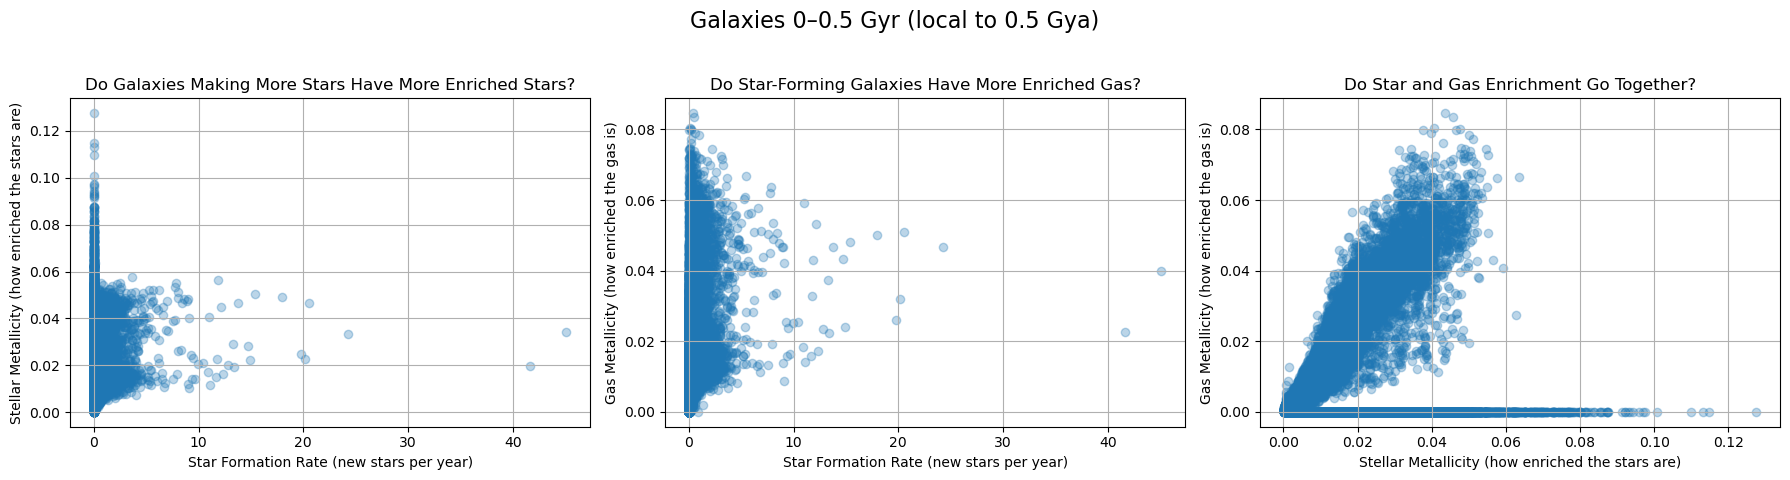

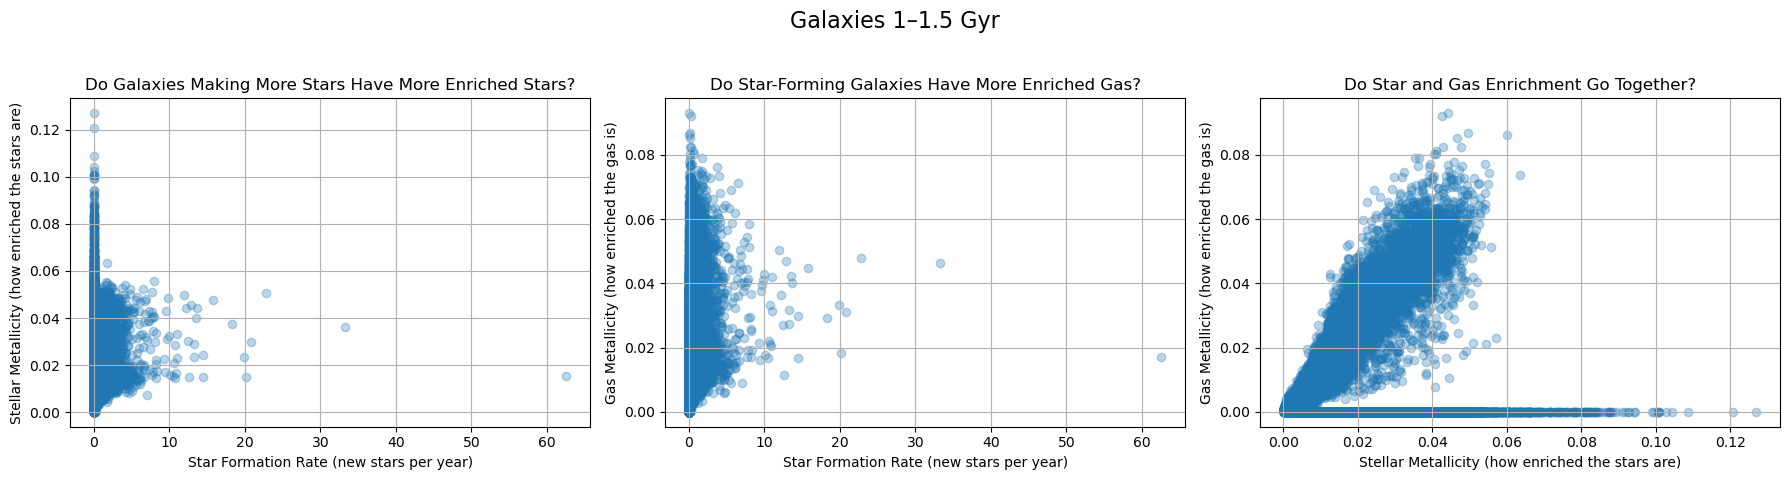

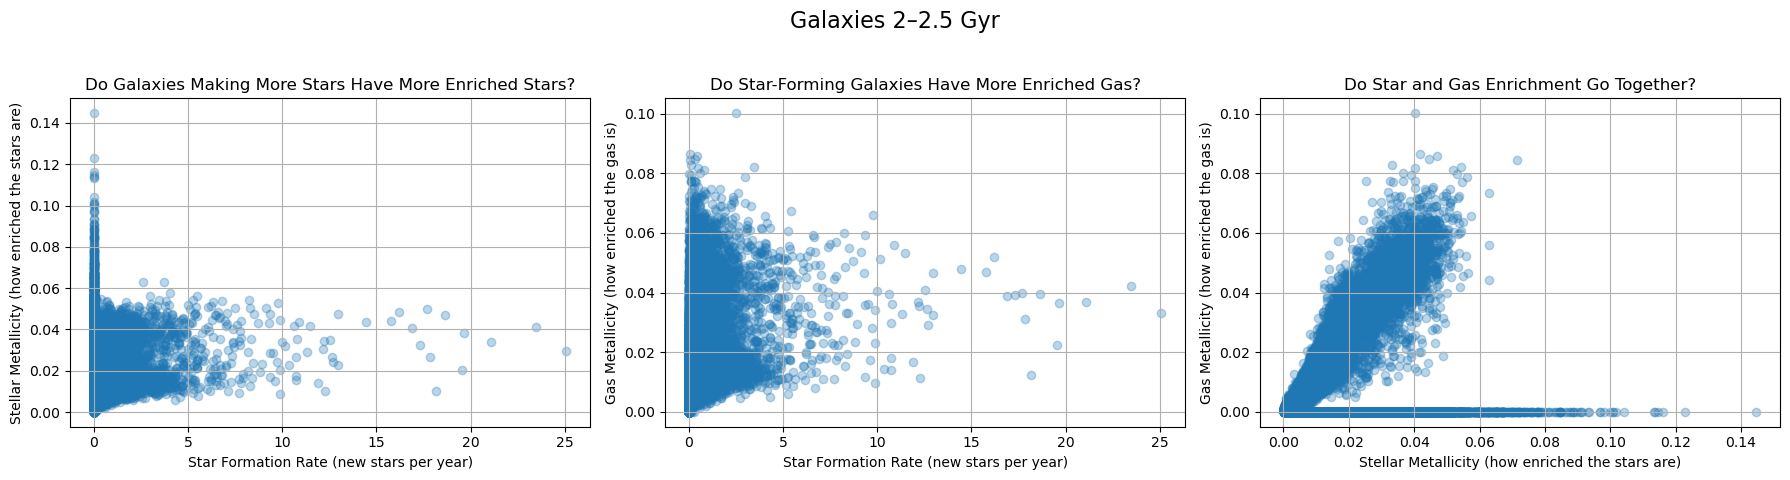

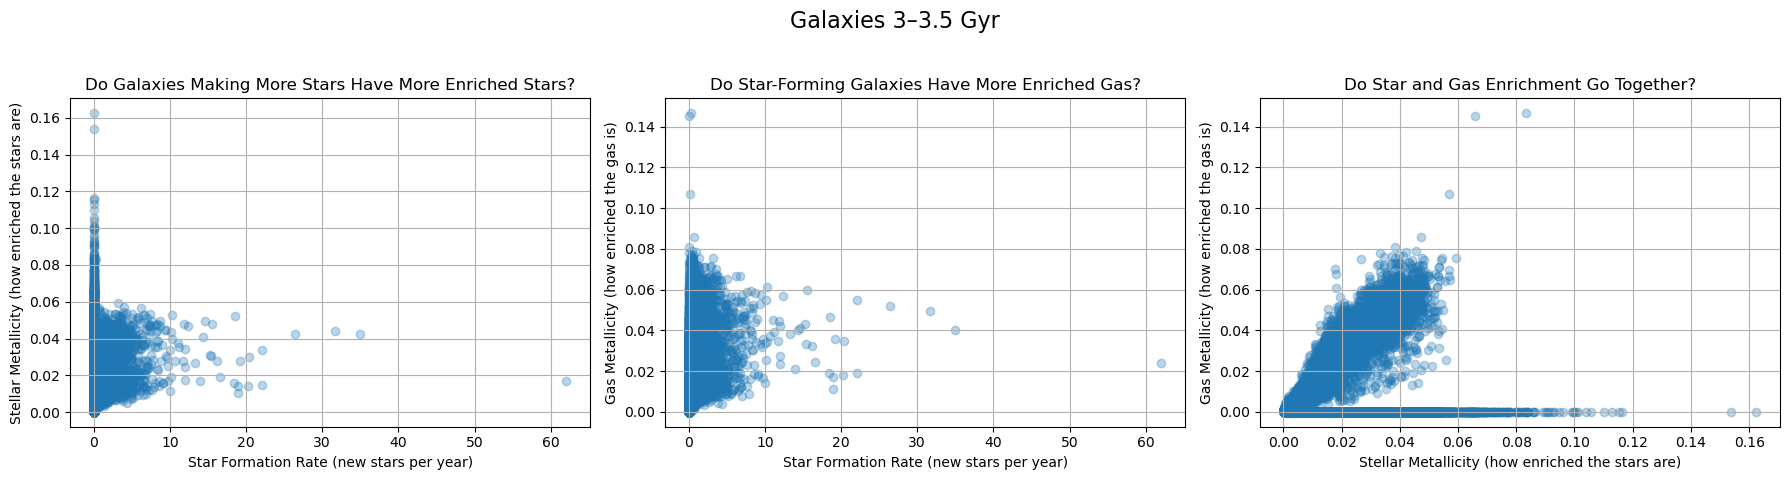

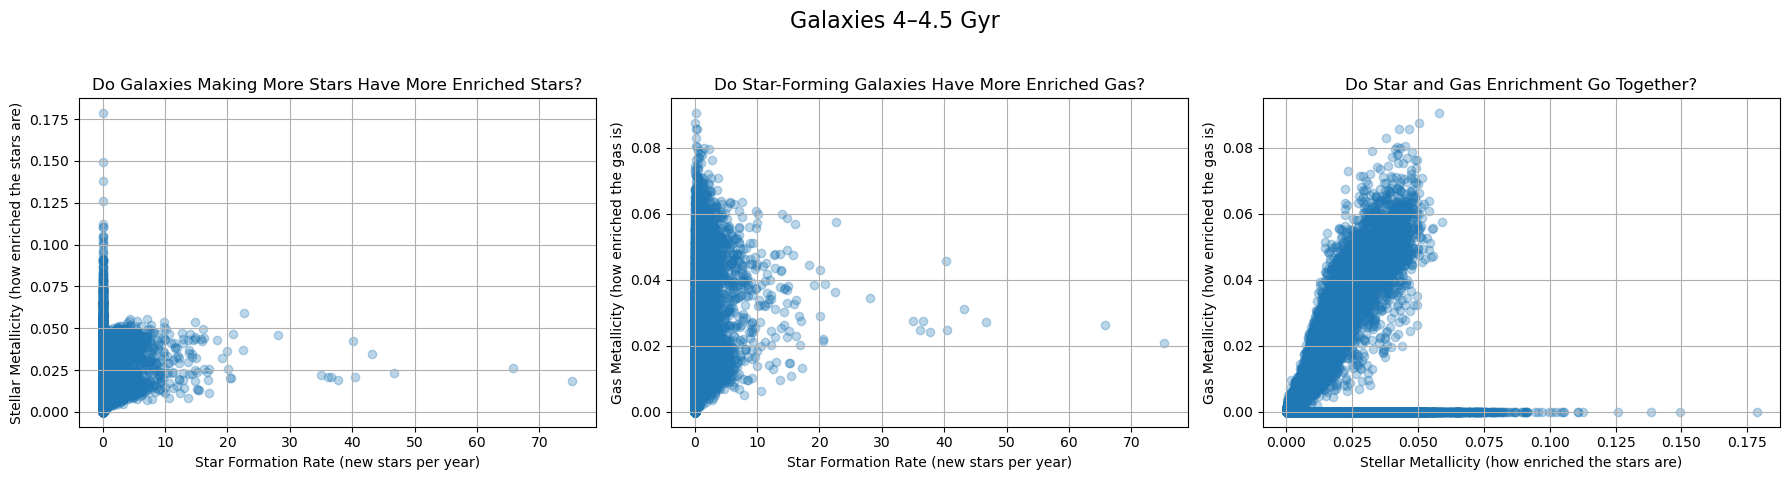

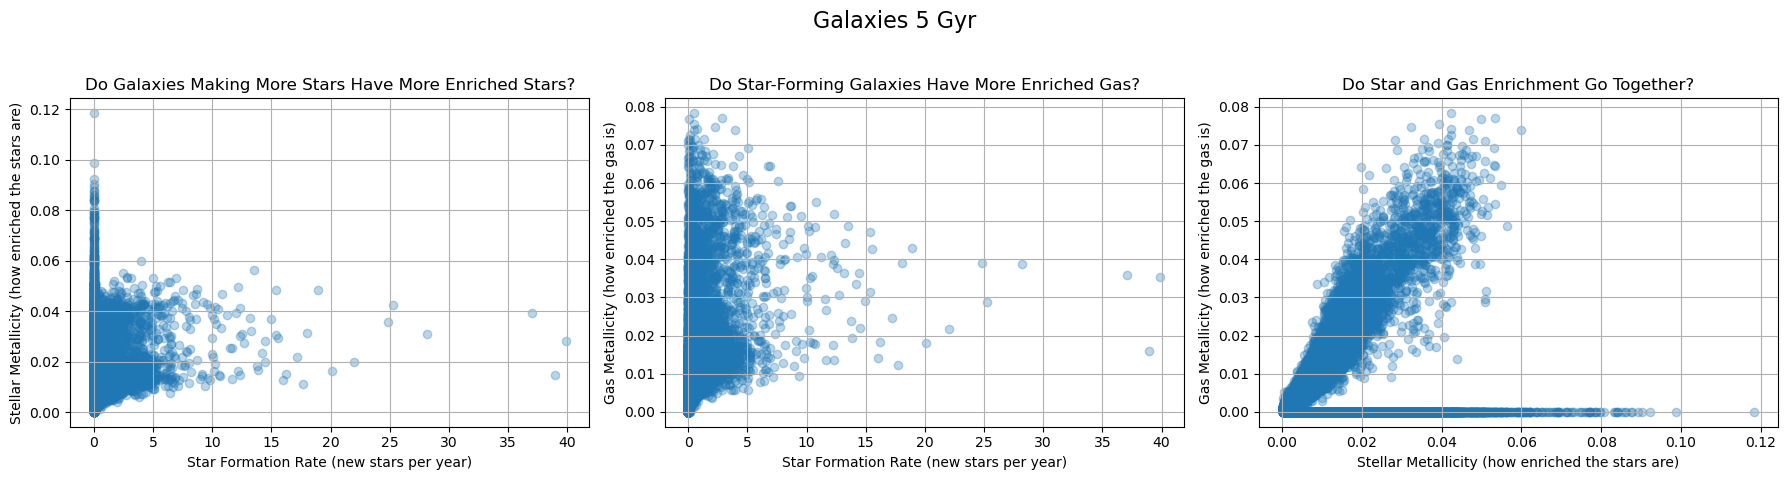

In [17]:
groups = [
    [data1, data2],
    [data3, data4],
    [data5, data6],
    [data7, data8],
    [data9, data10],
    [data11]
]

group_labels = [
    "0–0.5 Gyr (local to 0.5 Gya)",
    "1–1.5 Gyr",
    "2–2.5 Gyr",
    "3–3.5 Gyr",
    "4–4.5 Gyr",
    "5 Gyr"
]

# === Scatter Plots for Each Group (Layperson Friendly) ===
for i, group in enumerate(groups):
    combined = pd.concat(group)

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Galaxies {group_labels[i]}", fontsize=16)

    # Plot 1: Star Formation vs Stellar Enrichment
    axs[0].scatter(combined["SFR [Msun / yr]"], combined["Stellar Metallicity [Mz/Mtot]"], alpha=0.3)
    axs[0].set_xlabel("Star Formation Rate (new stars per year)")
    axs[0].set_ylabel("Stellar Metallicity (how enriched the stars are)")
    axs[0].set_title("Do Galaxies Making More Stars Have More Enriched Stars?")
    axs[0].grid(True)

    # Plot 2: Star Formation vs Gas Enrichment
    axs[1].scatter(combined["SFR [Msun / yr]"], combined["Gas Metallicity [Mz/Mtot]"], alpha=0.3)
    axs[1].set_xlabel("Star Formation Rate (new stars per year)")
    axs[1].set_ylabel("Gas Metallicity (how enriched the gas is)")
    axs[1].set_title("Do Star-Forming Galaxies Have More Enriched Gas?")
    axs[1].grid(True)

    # Plot 3: Stellar vs Gas Metallicity
    axs[2].scatter(combined["Stellar Metallicity [Mz/Mtot]"], combined["Gas Metallicity [Mz/Mtot]"], alpha=0.3)
    axs[2].set_xlabel("Stellar Metallicity (how enriched the stars are)")
    axs[2].set_ylabel("Gas Metallicity (how enriched the gas is)")
    axs[2].set_title("Do Star and Gas Enrichment Go Together?")
    axs[2].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    plt.savefig(f"galaxies_group_{i+1}.png")

    plt.show()






Outliers with SFR > 20:
       SFR [Msun / yr]  Stellar Metallicity [Mz/Mtot]  \
3365         20.531033                       0.046434   
3401         24.312070                       0.033499   
3446         45.123745                       0.034293   
18020        20.113340                       0.022475   
18284        41.628002                       0.019693   
33           22.822037                       0.050658   
8445         20.846832                       0.029766   
22158        20.185118                       0.015068   
3114         33.227460                       0.036293   
13202        62.577990                       0.015466   
8000         25.084496                       0.029773   
10079        23.462212                       0.041345   
14677        21.068762                       0.033824   
2943         22.055296                       0.033903   
12565        31.676136                       0.044363   
24061        20.200869                       0.014291   
26608  

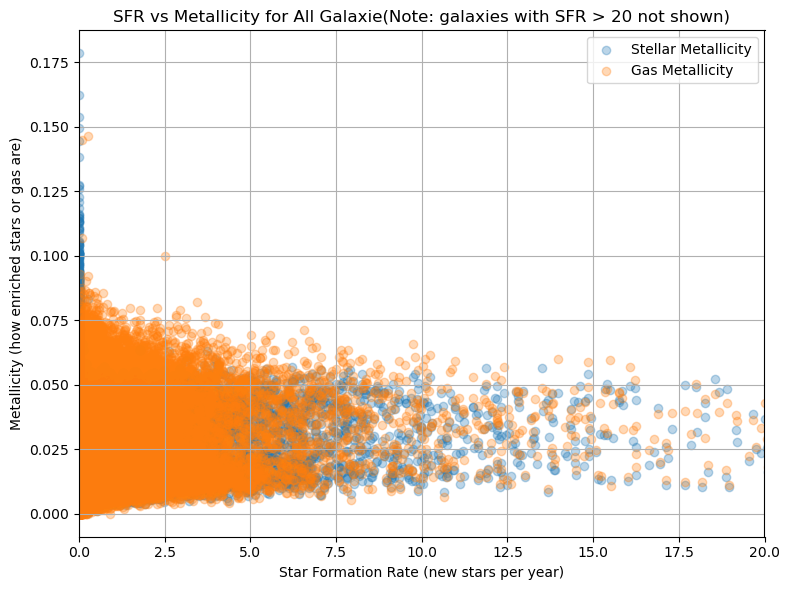

In [14]:
all_data = pd.concat([data1, data2, data3, data4, data5, data6, data7, data8, data9, data10, data11])

# Identify and print outliers where SFR > 10
outliers = all_data[all_data["SFR [Msun / yr]"] > 20]
print("Outliers with SFR > 20:")
print(outliers[["SFR [Msun / yr]", "Stellar Metallicity [Mz/Mtot]", "Gas Metallicity [Mz/Mtot]"]])

plt.figure(figsize=(8, 6))
plt.scatter(all_data["SFR [Msun / yr]"], all_data["Stellar Metallicity [Mz/Mtot]"], alpha=0.3, label="Stellar Metallicity")
plt.scatter(all_data["SFR [Msun / yr]"], all_data["Gas Metallicity [Mz/Mtot]"], alpha=0.3, label="Gas Metallicity")
plt.xlabel("Star Formation Rate (new stars per year)")
plt.ylabel("Metallicity (how enriched stars or gas are)")
plt.title("SFR vs Metallicity for All Galaxie(Note: galaxies with SFR > 20 not shown)")
plt.legend(loc="upper right")
plt.xlim(0, 20)
plt.grid(True)
plt.tight_layout()
plt.savefig("All Data Points Table.png")
plt.show()

